# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [1]:
from Tools.DatasetTools.Commoms import *
dataset = 'Fe-Mo'  # 'Cr-Co-W'#'Fe-Mo/'
components = dataset.split('-')
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer  import Featurizer
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)


In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)

# Compositions 

# Population of phases

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


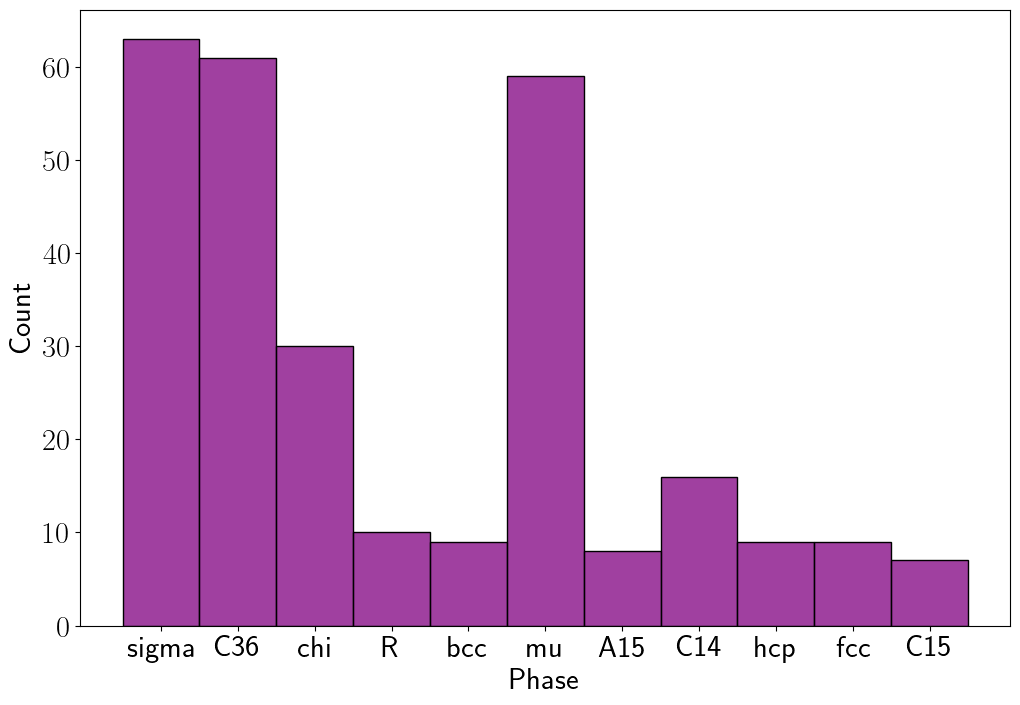

In [3]:
fig, ax = plt.subplots(figsize=(12,8))#, figsize=(12,8))
# sns.histplot(x = BS['Phase'], ax=ax)
#ax.hist(BS['Phase'])
ax = sns.histplot(x=BS['Phase'][BS['Phase']!='delta'], ax=ax, color='purple')
fig.savefig(f'{dataset}/graphs/{dataset}_ClassCounts.eps')
fig.savefig(f'{dataset}/graphs/{dataset}_ClassCounts.pdf')

In [4]:
BS['Phase'].value_counts()

sigma    63
C36      61
mu       59
chi      30
C14      16
R        10
bcc       9
hcp       9
fcc       9
A15       8
C15       7
delta     1
Name: Phase, dtype: int64

## Remove samples with very little representation

In [5]:
BS = BS[BS['Phase'] != 'delta']

# Extra features 

In [6]:
Features = Featurizer(BS)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


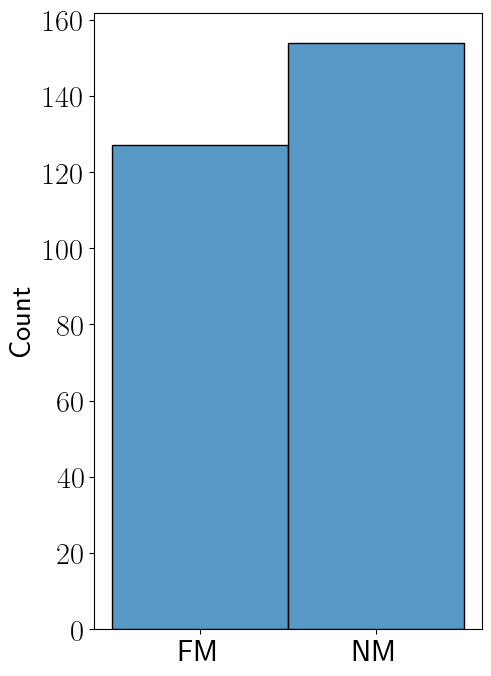

In [7]:
fig, ax = plt.subplots(figsize=(5,8))
sns.histplot(x = Features.Mag, ax=ax)
fig.savefig(f'{dataset}/graphs/{dataset}_FM_NM_counts.eps')

In [8]:
isfm = Features.Mag.str.contains('FM')

In [9]:
fmsamples = BS.index[isfm]

In [10]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [11]:
nmsamples = BS.index[~isfm]

## fm samples without nm counterpart:

In [12]:
nmsamples.difference(fmsamplesasnm)

Index(['Fe_pv10Mo_sv14.C36-ABBBA.NM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv11Mo_sv2.mu-AAABA.NM', 'Fe_pv11Mo_sv2.mu-AABAA.NM',
       'Fe_pv13.mu.NM', 'Fe_pv13Mo_sv16.chi-ABAB.NM',
       'Fe_pv14Mo_sv16.sigma-AABAB.NM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv18Mo_sv6.C36-AAABA.NM', 'Fe_pv1Mo_sv1.L10-NiAl-AB.NM',
       'Fe_pv1Mo_sv3.D03-AB3.NM', 'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM',
       'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM', 'Fe_pv28Mo_sv1.chi-BAAA.NM',
       'Fe_pv2Mo_sv2.B32-AB.NM', 'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM',
       'Fe_pv37Mo_sv14.R-AAAAAAAABBB.NM', 'Fe_pv3Mo_sv1.D03-A3B.NM',
       'Fe_pv3Mo_sv10.mu-ABBBA.NM', 'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM',
       'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM', 'Fe_pv53.R.NM',
       'Fe_pv5Mo_sv8.mu-ABBAA.NM', 'Fe_pv6.C15.NM',
       'Fe_pv6Mo_sv2.D0_19-A3B.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Mo_sv53.R.NM'],
      dtype='object')

## nm samples as without fm counterpart:

In [13]:
fmsamplesasnm.difference(nmsamples)

Index([], dtype='object')

# FM vs NM energies

#  Obvious outliers removal

In [15]:
BS = BS[(BS.B0 > 0 ) ]

In [16]:
minB0 = BS[BS['nelem']==1]['B0'].min()

In [17]:
maxB0 = BS[BS['nelem']==1]['B0'].max()

In [18]:
BS[BS['B0']>maxB0]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase


In [19]:
BS[BS['B0']<minB0]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase


# Distribution of Target Variables 

## total energy

In [20]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

In [21]:
if dataset == 'Cr-Co-W':
    BS = BS[(BS['E0']>-500) & (BS['V0']<40)]

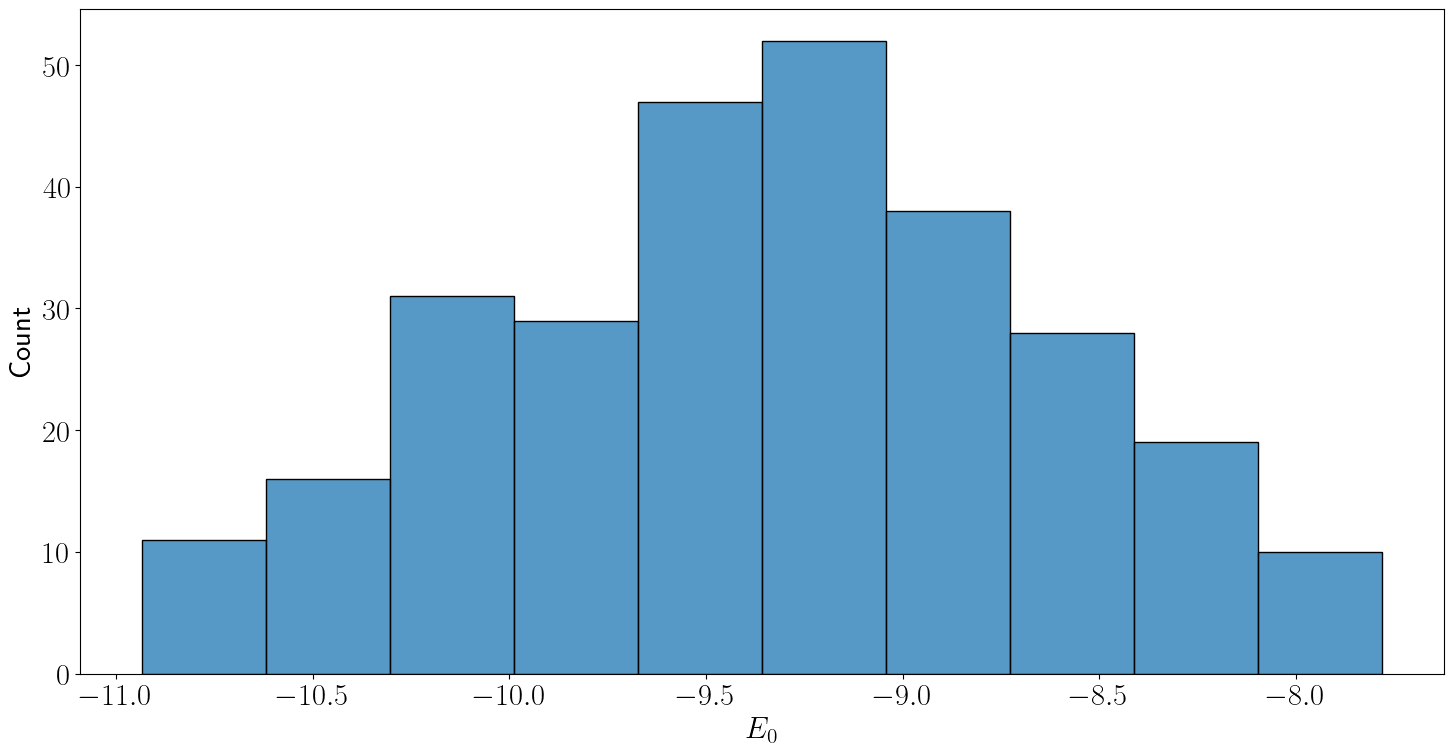

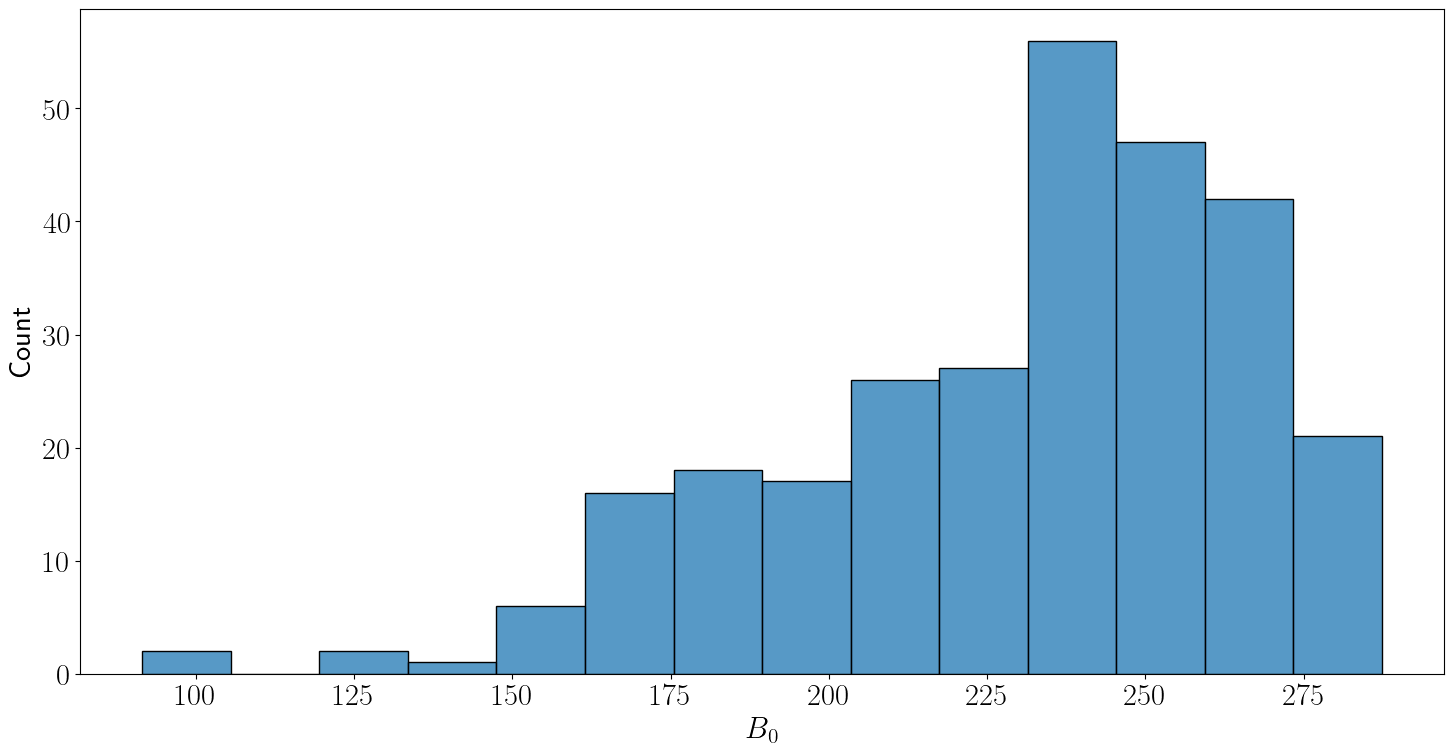

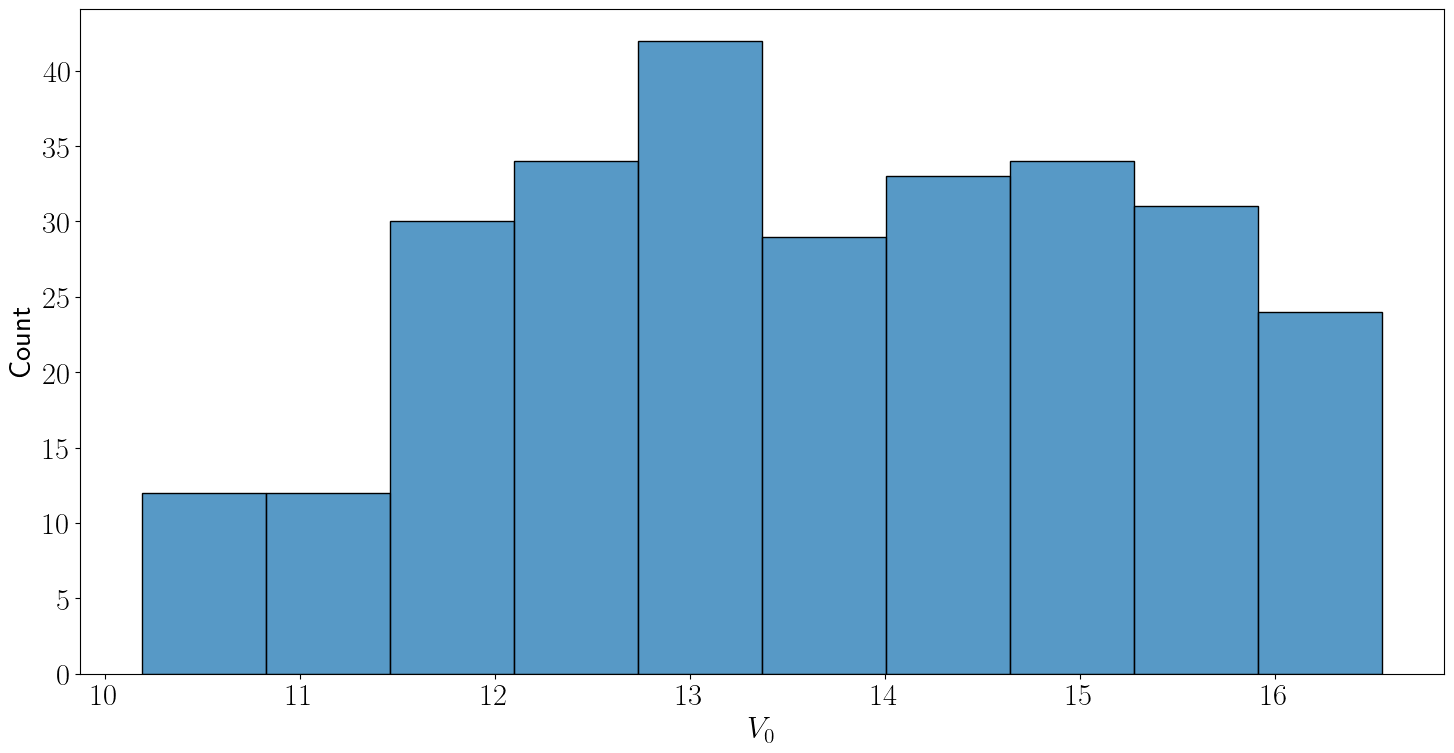

In [22]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [23]:
BS.sort_values(by='B0', inplace=True)

In [52]:
targets['EF'] = '$\Delta E_f$'

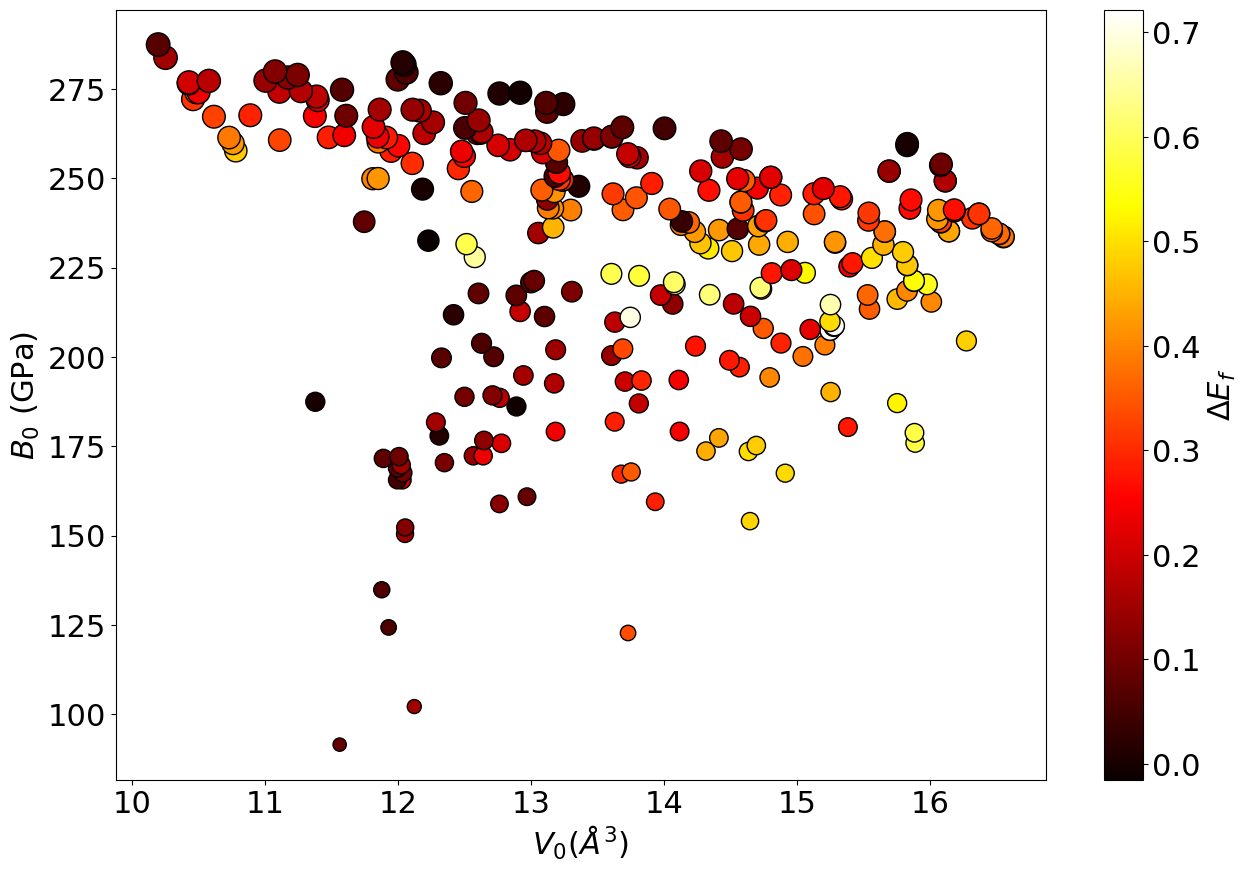

In [58]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.B0, c=BS.EF, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['B0']+' (GPa)')
plt.xlabel(targets['V0']+'($\AA^3$)')
cbar.set_label(targets['EF'])
#outlier_right = BS[(BS['E0']>-8) & (BS['V0']>14)].index
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )
#plt.annotate(outlier_right[0],*BS.loc[outlier_right][['V0', 'E0']].values,fontsize=16)
#outlier_high_b0 = BS[BS['B0']>1200].index
# plt.annotate(outlier_high_b0[0],*BS.loc[outlier_high_b0][['V0', 'E0']].values, fontsize=16)

from the plots below, we only would put in the paper the one with _V_0 in x, E_0 in y and B_0 in color coding_

# Pair Plots

In [25]:
ToPlot = BS[list(targets.keys())] #+['Phase']]
ToPlot.columns = list(targets.values()) #+['Phase']

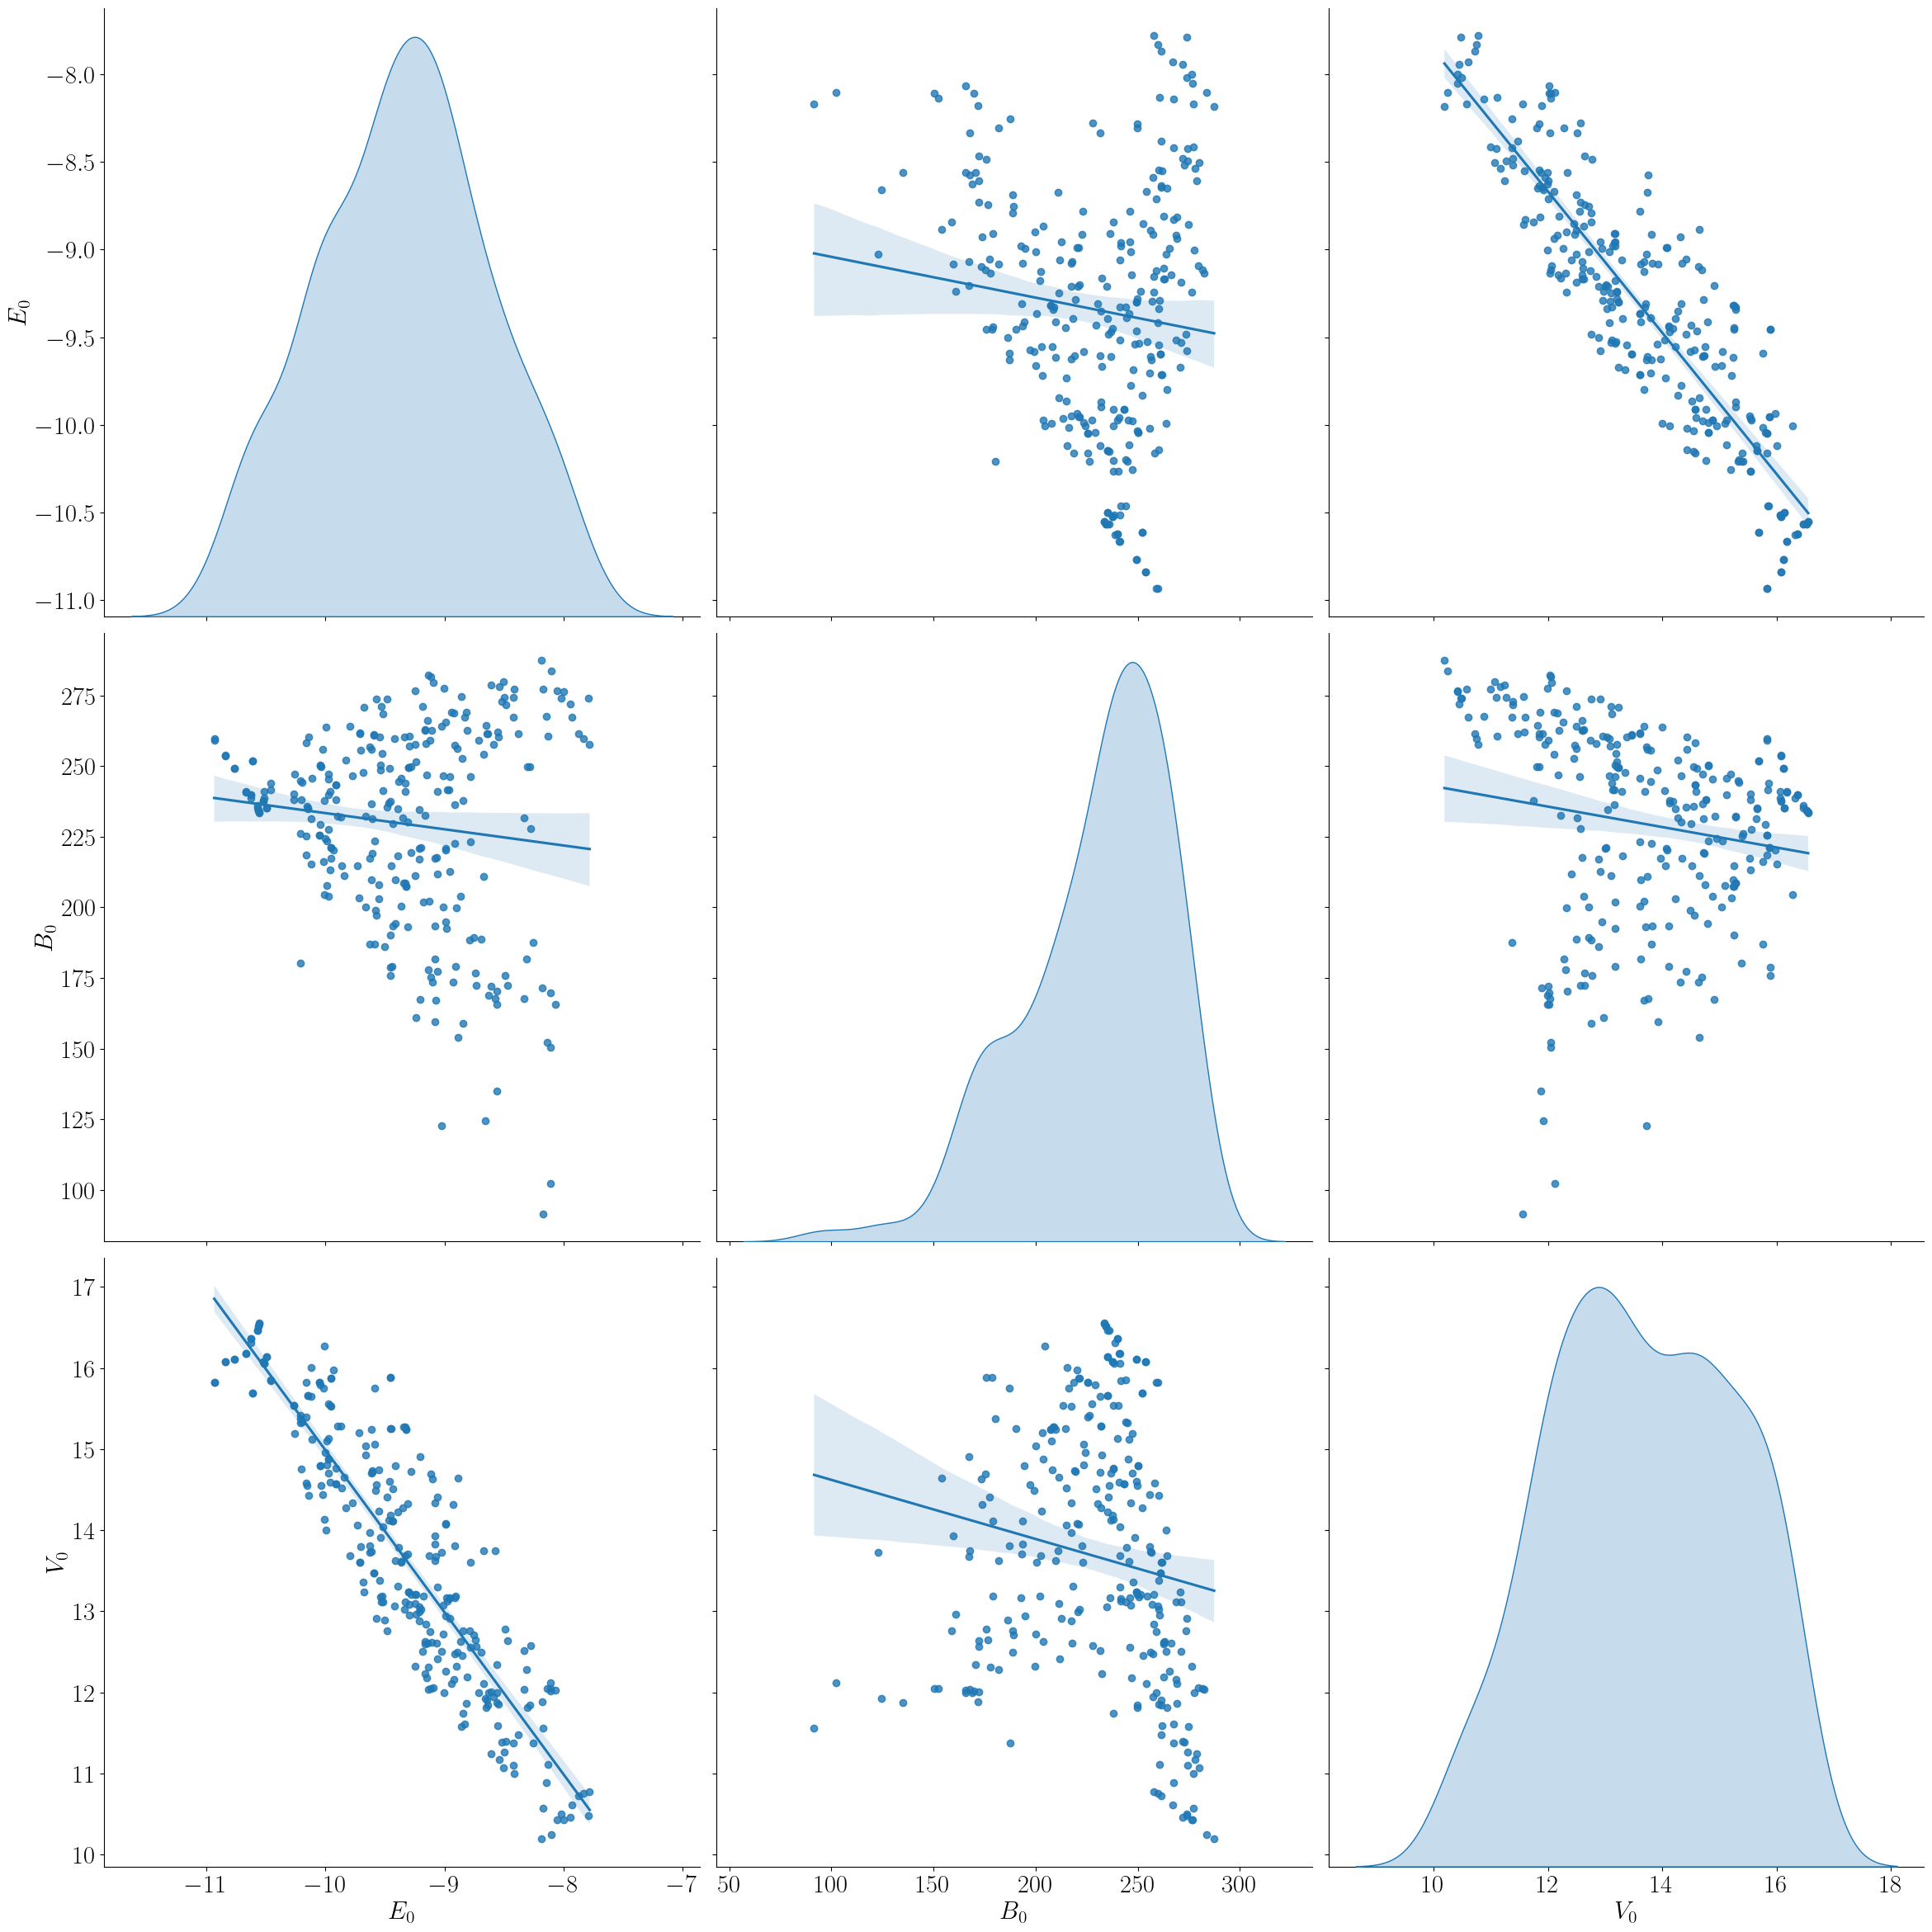

In [26]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# convex hulls (binaries only)

In [27]:
from Tools.DatasetTools.Tools import Plotting
P = Plotting()

In [28]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [29]:
components

['Fe', 'Mo']

In [30]:
PhaseBS = {}
verts = {}
chulls = {}
phasepoints = {}

PhaseBS = {phase: BS[BS.Phase == phase] for phase in BS.Phase.unique()}

points = P.get_x_ef_points(PhaseBS, components)
chulls = P.get_convex_hulls(PhaseBS, components, return_points = False)

In [50]:
BS['EF']

Fe_pv8.A15.FM                 0.085535
Fe_pv12.C14.FM                0.149303
Fe_pv17Mo_sv12.chi-AAAB.FM    0.337475
Fe_pv24Mo_sv5.chi-BBAA.FM      0.05852
Fe_pv25Mo_sv4.chi-ABAA.FM     0.063916
                                ...   
Fe_pv25Mo_sv4.chi-ABAA.NM     0.119258
Fe_pv16Mo_sv8.C36-BBAAA.NM    0.030551
Fe_pv8Mo_sv4.C14-BAA.NM       0.015189
Fe_pv4.fcc-cubic.NM           0.150295
Fe_pv2.hcp.NM                 0.071225
Name: EF, Length: 281, dtype: object

In [43]:
pallette

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


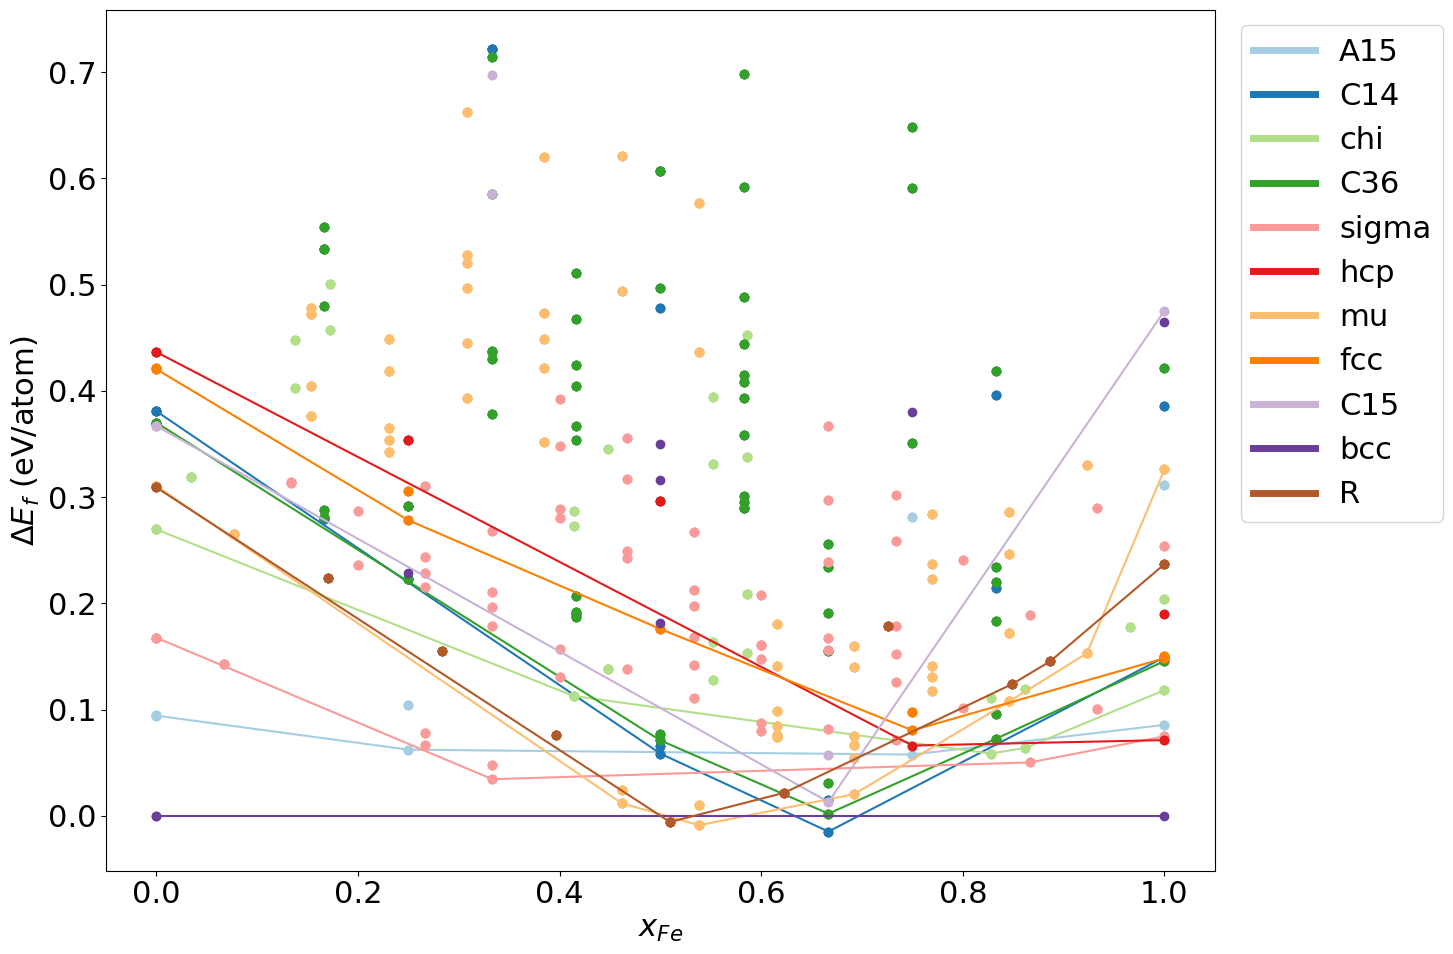

In [45]:
pallette = sns.color_palette("Paired", n_colors=len(PhaseBS)+1)
pallette.pop(-2)
colors = {phase: color for phase, color in zip(PhaseBS.keys(), pallette)}
fig, ax = plt.subplots()
labels=[]
handles = []
for phase, chull in chulls.items():
    for visible_facet in chull.simplices[chull.good]:
        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase])
    handles.append(l[0])
    labels.append(phase)
leg = ax.legend(handles, labels, bbox_to_anchor=(1.01,1))
setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
ax.set_xlabel(rf'$x_{{{components[0]}}}$')
fig.tight_layout()
fig.savefig(os.path.join(dataset, 'graphs',f'{dataset}_ConvxHulls.eps' ))

In [33]:
BS.to_pickle(os.path.join(dataset, f'FurtherCuratedParsedBriefSummary.pkl'))